# Mixed Curated/Random VAE Train Notebook

Notebook for training the attack-profile VAE on a `70%` curated v4 / `30%` random-baseline mixed dataset.

Default workflow:
1. Use or rebuild the mixed `45k / 5k` train-valid split.
2. Sanity-check the JSONL datasets.
3. Train the VAE and write checkpoints/artifacts.
4. Sample decoded profiles and compare their spawn distribution against the mixed training data.


## Imports


In [1]:
from __future__ import annotations

import csv
import json
import random
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import DataLoader

# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from convoy_sim.attack_profiles import AttackProfile
from convoy_sim.profile_audit import AuditThresholds, audit_attack_profiles
from convoy_sim.profile_generation_viz import (
    FIXED_X_LIMITS,
    apply_limits,
    combined_limits,
    plot_spawn_comparison,
    simple_ship_polygons,
    style_ax,
)
from convoy_sim.profile_outcome_audit import OutcomeAuditConfig
from convoy_sim.vae import (
    AttackProfileVAE,
    AttackProfileVAEPreprocessor,
    build_latent_bank,
    build_vae_datasets,
    load_attack_profile_dataset_jsonl,
    vae_loss,
)
from convoy_sim.vae_diagnostics import audit_decoded_vae_payloads, summarize_decoded_vae_audit
from convoy_sim.workflows import ensure_dir, git_sha, resolve_run_dir, write_json, write_yaml
from experiments.audit_attack_profile_dataset import flatten_dataset_records, load_dataset_records, summarize_flat_rows
from experiments.generate_attack_profile_scaffold import (
    MIN_SPAWN_CLEARANCE_M,
    generate_attack_profile_scaffolds,
    render_profiles_as_jsonl,
)
from scenarios.convoy_profiles import get_convoy_layout_profile

PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

In [2]:
#Set Seed
SEED = 1945

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Config


In [3]:
# Mixed dataset generation.
GENERATE_DATASETS = False
FORCE_REGENERATE_DATASETS = False
TRAIN_COUNT = 45_000
VALID_COUNT = 5_000
CURATED_FRACTION = 0.70
CONVOY_PROFILE = "convoy_layout_1"
TRAIN_SEED = 1945

CURATED_TRAIN_PATH = Path("data/attack_profiles/synthetic/train_random_tactical_v4_45k.jsonl")
CURATED_VALID_PATH = Path("data/attack_profiles/synthetic/valid_random_tactical_v4_5k.jsonl")
RANDOM_TRAIN_PATH = Path("data/attack_profiles/synthetic/train_random_profile_v1_45k.jsonl")
RANDOM_VALID_PATH = Path("data/attack_profiles/synthetic/valid_random_profile_v1_5k.jsonl")

TRAIN_PATH = Path("data/attack_profiles/synthetic/train_mixed_curated70_random30_45k.jsonl")
VALID_PATH = Path("data/attack_profiles/synthetic/valid_mixed_curated70_random30_5k.jsonl")

# Training.
RUN_TRAINING = False
EXISTING_RUN_DIR = Path("results/runs/vae/20260511_195317_mixed_curated70_random30_v1_notebook")
OUTPUT_ROOT = PROJECT_ROOT / "results" / "notebook-results" / "mixed_vae_train" / "runs"
RUN_NAME = "mixed_curated70_random30_v1_notebook"
DEVICE = "mps"  
SEED = 1945
EPOCHS = 60
BATCH_SIZE = 512
LEARNING_RATE = 1e-3
BETA = 0.03
LATENT_DIM = 6
HIDDEN_DIM = 64
NUM_WORKERS = 0
SAMPLE_COUNT = 1_000

# Post-training QA.
AUDIT_CONVOY_PROFILE = CONVOY_PROFILE
AUDIT_CHECKPOINT_NAME = "model_best.pt"
TRAIN_COMPARE_LIMIT = 5_000
MIN_SPAWN_CLEARANCE_M_FOR_DECODED = MIN_SPAWN_CLEARANCE_M
VAE_SAMPLE_METHOD = "latent_bank"  # prior or latent_bank
LATENT_BANK_NOISE_SCALE = 0.10
DYNAMIC_AUDIT_T_MAX_S = 600.0
DYNAMIC_AUDIT_DT_S = 0.5


## Helpers


In [4]:
def resolve_device(requested: str) -> str:
    if requested != "auto":
        return requested
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def mean_stats(stats_list: list[dict[str, float]]) -> dict[str, float]:
    if not stats_list:
        return {"loss": 0.0, "recon_loss": 0.0, "kl_loss": 0.0, "beta": 0.0}
    keys = stats_list[0].keys()
    return {key: float(np.mean([item[key] for item in stats_list], dtype=float)) for key in keys}


def train_one_epoch(model, data_loader, optimizer, device: str, beta: float) -> dict[str, float]:
    model.train()
    batch_stats = []
    for batch in data_loader:
        batch = batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        recon, mu, logvar = model(batch)
        loss, stats = vae_loss(recon, batch, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        batch_stats.append(stats)
    return mean_stats(batch_stats)


def eval_one_epoch(model, data_loader, device: str, beta: float) -> dict[str, float]:
    model.eval()
    batch_stats = []
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            recon, mu, logvar = model(batch)
            _, stats = vae_loss(recon, batch, mu, logvar, beta=beta)
            batch_stats.append(stats)
    return mean_stats(batch_stats)


def write_history_csv(path: Path, history: list[dict[str, float]]) -> None:
    ensure_dir(path.parent)
    fieldnames = [
        "epoch",
        "train_loss",
        "train_recon_loss",
        "train_kl_loss",
        "valid_loss",
        "valid_recon_loss",
        "valid_kl_loss",
    ]
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in history:
            writer.writerow(row)


## Optional Mixed Dataset Build


In [5]:
def build_mixed_dataset_jsonl(*, force: bool = False) -> tuple[Path, Path]:
    train_output = PROJECT_ROOT / TRAIN_PATH
    valid_output = PROJECT_ROOT / VALID_PATH
    if train_output.exists() and valid_output.exists() and not force:
        print(f"Using existing mixed datasets:\n- {train_output}\n- {valid_output}")
        return train_output, valid_output

    cmd = [
        sys.executable,
        "-m",
        "experiments.build_mixed_attack_profile_dataset",
        "--curated-train",
        str(CURATED_TRAIN_PATH),
        "--random-train",
        str(RANDOM_TRAIN_PATH),
        "--curated-valid",
        str(CURATED_VALID_PATH),
        "--random-valid",
        str(RANDOM_VALID_PATH),
        "--train-output",
        str(TRAIN_PATH),
        "--valid-output",
        str(VALID_PATH),
        "--train-count",
        str(int(TRAIN_COUNT)),
        "--valid-count",
        str(int(VALID_COUNT)),
        "--curated-fraction",
        str(float(CURATED_FRACTION)),
        "--seed",
        str(int(TRAIN_SEED)),
    ]
    if force:
        cmd.append("--overwrite")
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
    return train_output, valid_output


if GENERATE_DATASETS:
    build_mixed_dataset_jsonl(force=FORCE_REGENERATE_DATASETS)
else:
    print("Dataset generation set to False; expecting mixed JSONL files to already exist.")


Dataset generation set to False; expecting mixed JSONL files to already exist.


## Dataset Sanity Check


In [6]:
def dataset_summary(path: Path, *, limit: int | None = None) -> dict:
    records = load_dataset_records(PROJECT_ROOT / path)
    inspect_records = records if limit is None else records[: int(limit)]
    flat_rows = flatten_dataset_records(inspect_records)
    summary = summarize_flat_rows(flat_rows)
    summary["path"] = str(path)
    summary["record_count_on_disk"] = len(records)
    return summary


missing = [str(path) for path in [PROJECT_ROOT / TRAIN_PATH, PROJECT_ROOT / VALID_PATH] if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing dataset file(s): " + ", ".join(missing) + ". "
        "Set GENERATE_DATASETS = True, or update TRAIN_PATH / VALID_PATH."
    )

train_summary = dataset_summary(TRAIN_PATH, limit=TRAIN_COMPARE_LIMIT)
valid_summary = dataset_summary(VALID_PATH, limit=None)
train_summary, valid_summary


({'profile_count': 5000,
  'labels': {'credible_hit_threat': 3242,
   'credible_near_miss': 1269,
   'intentional_miss': 489},
  'approach_families': {'unknown': 5000},
  'range_bands': {'unknown': 5000},
  'target_zone_kinds': {'lead_column': 690,
   'port_edge': 492,
   'starboard_edge': 497,
   'profile_first_random': 1526,
   'interior': 1179,
   'trailing_column': 616},
  'spawn_regions': {'ahead_beam': 695,
   'outside_perimeter': 1142,
   'inside_columns': 551,
   'beam_attack': 487,
   'astern_random': 268,
   'ahead_random': 405,
   'inside_convoy_envelope': 363,
   'astern_infiltration': 599,
   'port_random': 251,
   'starboard_random': 239},
  'inside_convoy_envelope': {'true': 1113, 'false': 3887},
  'approach_sides': {'port_forward_quarter': 129,
   'port': 927,
   'inside_columns': 750,
   'port_aft_quarter': 99,
   'astern': 944,
   'ahead': 1323,
   'starboard_forward_quarter': 115,
   'inside': 363,
   'starboard': 239,
   'starboard_aft_quarter': 111},
  'approach_la

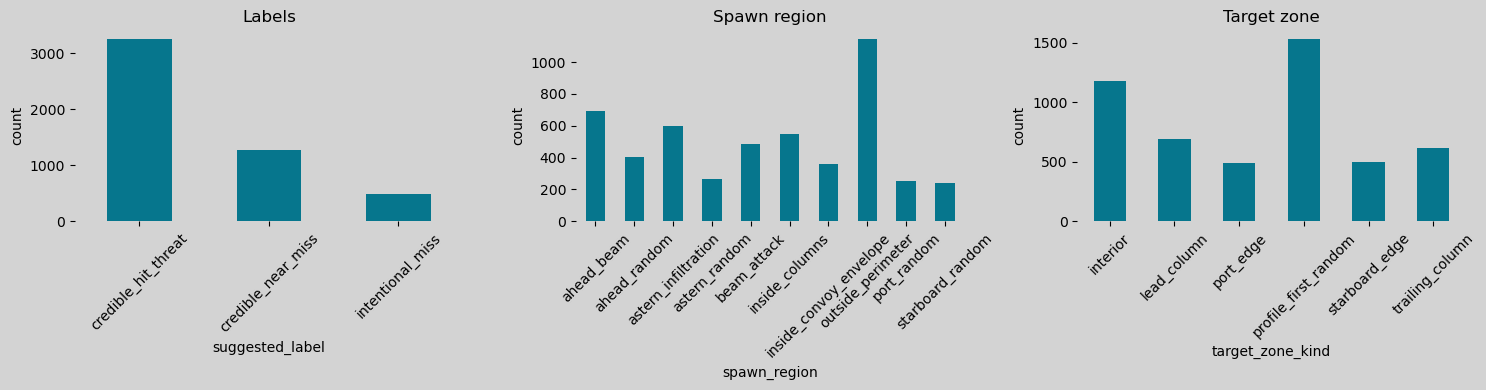

In [7]:
train_records_preview = load_dataset_records(PROJECT_ROOT / TRAIN_PATH)[: int(TRAIN_COMPARE_LIMIT)]
train_rows_preview = flatten_dataset_records(train_records_preview)
train_df_preview = pd.DataFrame(train_rows_preview)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor="lightgrey")
for ax, column, title in [
    (axes[0], "suggested_label", "Labels"),
    (axes[1], "spawn_region", "Spawn region"),
    (axes[2], "target_zone_kind", "Target zone"),
]:
    ax.set_facecolor("lightgrey")
    counts = train_df_preview[column].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, color="#06768d")
    ax.set_title(title)
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()


## Training


In [8]:
def run_training_notebook() -> Path:
    overall_start = time.perf_counter()
    seed_everything(int(SEED))
    device = resolve_device(DEVICE)
    output_root = PROJECT_ROOT / OUTPUT_ROOT
    run_dir = resolve_run_dir(output_root, "vae", RUN_NAME)
    checkpoint_dir = run_dir / "checkpoints"
    ensure_dir(checkpoint_dir)

    data_start = time.perf_counter()
    train_ds, valid_ds, preprocessor = build_vae_datasets(
        train_path=PROJECT_ROOT / TRAIN_PATH,
        valid_path=PROJECT_ROOT / VALID_PATH,
    )
    data_seconds = time.perf_counter() - data_start

    generator = torch.Generator().manual_seed(int(SEED))
    train_loader = DataLoader(
        train_ds,
        batch_size=int(BATCH_SIZE),
        shuffle=True,
        generator=generator,
        num_workers=int(NUM_WORKERS),
    )
    valid_loader = DataLoader(
        valid_ds,
        batch_size=int(BATCH_SIZE),
        shuffle=False,
        num_workers=int(NUM_WORKERS),
    )

    model = AttackProfileVAE(latent_dim=int(LATENT_DIM), hidden_dim=int(HIDDEN_DIM)).to(device)
    optimizer = Adam(model.parameters(), lr=float(LEARNING_RATE))

    history = []
    best_valid_loss = float("inf")
    best_epoch = 0
    train_start = time.perf_counter()

    for epoch in range(1, int(EPOCHS) + 1):
        train_stats = train_one_epoch(model, train_loader, optimizer, device, float(BETA))
        valid_stats = eval_one_epoch(model, valid_loader, device, float(BETA))
        row = {
            "epoch": int(epoch),
            "train_loss": float(train_stats["loss"]),
            "train_recon_loss": float(train_stats["recon_loss"]),
            "train_kl_loss": float(train_stats["kl_loss"]),
            "valid_loss": float(valid_stats["loss"]),
            "valid_recon_loss": float(valid_stats["recon_loss"]),
            "valid_kl_loss": float(valid_stats["kl_loss"]),
        }
        history.append(row)
        best_marker = ""
        if row["valid_loss"] < best_valid_loss:
            best_valid_loss = row["valid_loss"]
            best_epoch = int(epoch)
            best_marker = " *best"
            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "preprocessor": preprocessor.to_dict(),
                "hyperparameters": {
                    "latent_dim": int(LATENT_DIM),
                    "hidden_dim": int(HIDDEN_DIM),
                    "learning_rate": float(LEARNING_RATE),
                    "batch_size": int(BATCH_SIZE),
                    "beta": float(BETA),
                },
            }, checkpoint_dir / "model_best.pt")
        print(
            f"epoch {epoch:03d} | "
            f"train_loss={row['train_loss']:.4f} "
            f"train_recon={row['train_recon_loss']:.4f} "
            f"train_kl={row['train_kl_loss']:.4f} | "
            f"valid_loss={row['valid_loss']:.4f} "
            f"valid_recon={row['valid_recon_loss']:.4f} "
            f"valid_kl={row['valid_kl_loss']:.4f}"
            f"{best_marker}"
        )

    training_seconds = time.perf_counter() - train_start
    torch.save({
        "epoch": int(EPOCHS),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "preprocessor": preprocessor.to_dict(),
        "hyperparameters": {
            "latent_dim": int(LATENT_DIM),
            "hidden_dim": int(HIDDEN_DIM),
            "learning_rate": float(LEARNING_RATE),
            "batch_size": int(BATCH_SIZE),
            "beta": float(BETA),
        },
    }, checkpoint_dir / "model_latest.pt")

    sample_start = time.perf_counter()
    model.eval()
    sample_device = torch.device(device)
    if str(VAE_SAMPLE_METHOD) == "prior":
        with torch.no_grad():
            decoded = model.sample(int(SAMPLE_COUNT), device=sample_device).cpu().numpy()
    elif str(VAE_SAMPLE_METHOD) == "latent_bank":
        latent_bank = build_latent_bank(model, train_ds.features, device=sample_device)
        with torch.no_grad():
            decoded = model.sample_from_latent_bank(
                latent_bank,
                int(SAMPLE_COUNT),
                noise_scale=float(LATENT_BANK_NOISE_SCALE),
                device=sample_device,
            ).cpu().numpy()
    else:
        raise ValueError("VAE_SAMPLE_METHOD must be 'prior' or 'latent_bank'")
    sample_payload = [
        preprocessor.decode_profile_fields(
            decoded[idx],
            profile_id=f"VAE_SAMPLE_{idx + 1:04d}",
            name=f"vae_sample_{idx + 1:04d}",
        )
        for idx in range(int(SAMPLE_COUNT))
    ]
    sample_seconds = time.perf_counter() - sample_start

    write_history_csv(run_dir / "training_history.csv", history)
    write_json(run_dir / "sampled_profiles.json", {"profiles": sample_payload})

    final_train = history[-1]
    best_row = history[best_epoch - 1]
    metrics_summary = {
        "dataset": {
            "train_samples": int(len(train_ds)),
            "valid_samples": int(len(valid_ds)),
            "input_dim": int(model.input_dim),
            "feature_names": list(preprocessor.feature_names),
        },
        "model": {
            "latent_dim": int(model.latent_dim),
            "hidden_dim": int(model.hidden_dim),
            "parameter_count": int(sum(int(p.numel()) for p in model.parameters())),
            "beta": float(BETA),
        },
        "training": {
            "epochs": int(EPOCHS),
            "batch_size": int(BATCH_SIZE),
            "learning_rate": float(LEARNING_RATE),
            "best_epoch": int(best_epoch),
            "final_train_loss": float(final_train["train_loss"]),
            "final_train_recon_loss": float(final_train["train_recon_loss"]),
            "final_train_kl_loss": float(final_train["train_kl_loss"]),
            "final_valid_loss": float(final_train["valid_loss"]),
            "final_valid_recon_loss": float(final_train["valid_recon_loss"]),
            "final_valid_kl_loss": float(final_train["valid_kl_loss"]),
            "best_valid_loss": float(best_row["valid_loss"]),
            "best_valid_recon_loss": float(best_row["valid_recon_loss"]),
            "best_valid_kl_loss": float(best_row["valid_kl_loss"]),
        },
        "samples": {
            "count": int(SAMPLE_COUNT),
            "sampling_method": str(VAE_SAMPLE_METHOD),
            "latent_noise_scale": float(LATENT_BANK_NOISE_SCALE),
            "output_file": "sampled_profiles.json",
        },
        "timing": {
            "dataset_load_seconds": float(data_seconds),
            "training_seconds": float(training_seconds),
            "sample_decode_seconds": float(sample_seconds),
            "total_seconds": float(time.perf_counter() - overall_start),
        },
    }
    manifest = {
        "workflow": "vae_train_notebook",
        "git_sha": git_sha(PROJECT_ROOT),
        "device": device,
        "seed": int(SEED),
        "train_path": str(TRAIN_PATH),
        "valid_path": str(VALID_PATH),
        "output_root": str(OUTPUT_ROOT),
        "run_name": str(RUN_NAME),
        "hyperparameters": {
            "epochs": int(EPOCHS),
            "batch_size": int(BATCH_SIZE),
            "learning_rate": float(LEARNING_RATE),
            "beta": float(BETA),
            "latent_dim": int(LATENT_DIM),
            "hidden_dim": int(HIDDEN_DIM),
            "sample_count": int(SAMPLE_COUNT),
            "sample_method": str(VAE_SAMPLE_METHOD),
            "latent_noise_scale": float(LATENT_BANK_NOISE_SCALE),
        },
        "preprocessor": preprocessor.to_dict(),
        "artifacts": {
            "history_csv": "training_history.csv",
            "metrics_summary_json": "metrics_summary.json",
            "run_manifest_json": "run_manifest.json",
            "best_checkpoint": "checkpoints/model_best.pt",
            "latest_checkpoint": "checkpoints/model_latest.pt",
            "sampled_profiles_json": "sampled_profiles.json",
        },
    }
    resolved_cfg = {
        "dataset": {
            "train_path": str(TRAIN_PATH),
            "valid_path": str(VALID_PATH),
        },
        "training": {
            "epochs": int(EPOCHS),
            "batch_size": int(BATCH_SIZE),
            "learning_rate": float(LEARNING_RATE),
            "beta": float(BETA),
            "latent_dim": int(LATENT_DIM),
            "hidden_dim": int(HIDDEN_DIM),
            "device": device,
            "num_workers": int(NUM_WORKERS),
            "sample_count": int(SAMPLE_COUNT),
            "seed": int(SEED),
        },
    }

    write_yaml(run_dir / "config_resolved.yaml", resolved_cfg)
    write_json(run_dir / "metrics_summary.json", metrics_summary)
    write_json(run_dir / "run_manifest.json", manifest)
    return run_dir


In [9]:
if RUN_TRAINING:
    RUN_DIR = run_training_notebook()
else:
    RUN_DIR = PROJECT_ROOT / EXISTING_RUN_DIR
    if not RUN_DIR.exists():
        raise ValueError("Set EXISTING_RUN_DIR to an existing run when RUN_TRAINING is False")

RUN_DIR


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/vae/20260511_195317_mixed_curated70_random30_v1_notebook')

## Training History


In [10]:
history_df = pd.read_csv(RUN_DIR / "training_history.csv")
metrics_summary = json.loads((RUN_DIR / "metrics_summary.json").read_text(encoding="utf-8"))
metrics_summary


{'dataset': {'train_samples': 45000,
  'valid_samples': 5000,
  'input_dim': 8,
  'feature_names': ['u_pos_x',
   'u_pos_y',
   'sin_base_bearing_rad',
   'cos_base_bearing_rad',
   'spread_rad',
   'launch_delay_s',
   'salvo_interval_s',
   'u_boat_initial_speed_mps']},
 'model': {'latent_dim': 6,
  'hidden_dim': 64,
  'parameter_count': 10644,
  'beta': 0.03},
 'training': {'epochs': 60,
  'batch_size': 512,
  'learning_rate': 0.001,
  'best_epoch': 60,
  'final_train_loss': 0.3315960510887883,
  'final_train_recon_loss': 0.11871802756054835,
  'final_train_kl_loss': 7.095934250138023,
  'final_valid_loss': 0.33237878382205965,
  'final_valid_recon_loss': 0.12082854360342025,
  'final_valid_kl_loss': 7.051674890518188,
  'best_valid_loss': 0.33237878382205965,
  'best_valid_recon_loss': 0.12082854360342025,
  'best_valid_kl_loss': 7.051674890518188},
 'samples': {'count': 1000,
  'sampling_method': 'latent_bank',
  'latent_noise_scale': 0.1,
  'output_file': 'sampled_profiles.json'}

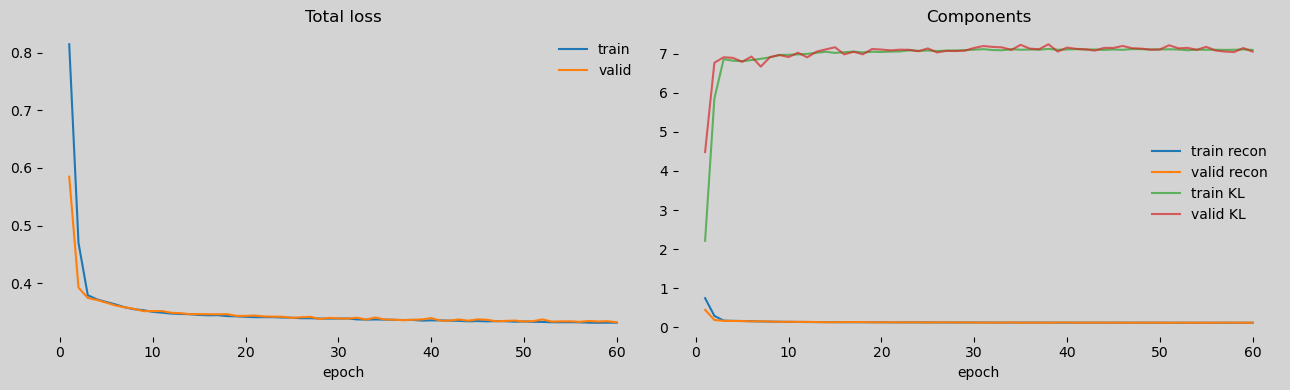

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor="lightgrey")
#Left Plot
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["valid_loss"], label="valid")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
axes[0].legend(frameon=False)
#Right Plot
axes[1].plot(history_df["epoch"], history_df["train_recon_loss"], label="train recon")
axes[1].plot(history_df["epoch"], history_df["valid_recon_loss"], label="valid recon")
axes[1].plot(history_df["epoch"], history_df["train_kl_loss"], label="train KL", alpha=0.7)
axes[1].plot(history_df["epoch"], history_df["valid_kl_loss"], label="valid KL", alpha=0.7)
axes[1].set_title("Components")
axes[1].set_xlabel("epoch")
axes[1].legend(frameon=False)
for ax in axes:
    ax.set_facecolor("lightgrey")
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.savefig("Mixed_Loss_Plot.png")
plt.show()


## Sample From Checkpoint

Decoded VAE samples do not currently include target intent labels. The audit below is therefore a coarse geometry sanity check, not a replacement for the v4 outcome-gated data-generation audit.


In [12]:
def sample_profiles_from_checkpoint(
    run_dir: Path,
    *,
    checkpoint_name: str,
    sample_count: int,
    device: str = "cpu",
    sampling_method: str = "prior",
    train_path: Path | None = None,
    latent_noise_scale: float = 0.10,
    seed: int = 1945,
) -> tuple[list[dict], AttackProfileVAEPreprocessor, dict]:
    manifest = json.loads((run_dir / "run_manifest.json").read_text(encoding="utf-8"))
    checkpoint = torch.load(run_dir / "checkpoints" / checkpoint_name, map_location=device)
    preprocessor_payload = checkpoint.get("preprocessor", manifest["preprocessor"])
    preprocessor = AttackProfileVAEPreprocessor.from_dict(preprocessor_payload)
    hyper = checkpoint.get("hyperparameters", manifest["hyperparameters"])
    model = AttackProfileVAE(latent_dim=int(hyper["latent_dim"]), hidden_dim=int(hyper["hidden_dim"]))
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    sample_device = torch.device(device)
    torch.manual_seed(int(seed))
    if str(sampling_method) == "prior":
        with torch.no_grad():
            decoded = model.sample(int(sample_count), device=sample_device).cpu().numpy()
    elif str(sampling_method) == "latent_bank":
        if train_path is None:
            raise ValueError("train_path is required for latent_bank sampling")
        train_records_for_bank = load_attack_profile_dataset_jsonl(train_path)
        train_features_for_bank = preprocessor.transform_records(train_records_for_bank)
        latent_bank = build_latent_bank(model, train_features_for_bank, device=sample_device)
        with torch.no_grad():
            decoded = model.sample_from_latent_bank(
                latent_bank,
                int(sample_count),
                noise_scale=float(latent_noise_scale),
                device=sample_device,
            ).cpu().numpy()
    else:
        raise ValueError("sampling_method must be 'prior' or 'latent_bank'")

    payloads = [
        preprocessor.decode_profile_fields(
            decoded[idx],
            profile_id=f"VAE_AUDIT_{idx + 1:04d}",
            name=f"vae_audit_{idx + 1:04d}",
        )
        for idx in range(int(sample_count))
    ]
    manifest = dict(manifest)
    manifest["decoded_sample_method"] = str(sampling_method)
    manifest["decoded_latent_noise_scale"] = float(latent_noise_scale)
    return payloads, preprocessor, manifest


def audit_decoded_payloads(payloads: list[dict], *, convoy_profile: str) -> tuple[list, list[AttackProfile], list[dict], pd.DataFrame]:
    ships = get_convoy_layout_profile(convoy_profile).build_ships()
    profiles = [AttackProfile(**payload) for payload in payloads]
    audit_rows = audit_decoded_vae_payloads(
        payloads,
        ships,
        min_clearance_m=float(MIN_SPAWN_CLEARANCE_M_FOR_DECODED),
        rng_seed=int(AUDIT_SEED if "AUDIT_SEED" in globals() else SEED),
        outcome_cfg=OutcomeAuditConfig(t_max_s=float(DYNAMIC_AUDIT_T_MAX_S), hit_dt_s=float(DYNAMIC_AUDIT_DT_S)),
    )
    return ships, profiles, audit_rows, pd.DataFrame(audit_rows)


In [13]:
device_for_sampling = resolve_device(DEVICE)
AUDIT_PAYLOADS, AUDIT_PREPROCESSOR, AUDIT_MANIFEST = sample_profiles_from_checkpoint(
    RUN_DIR,
    checkpoint_name=AUDIT_CHECKPOINT_NAME,
    sample_count=int(SAMPLE_COUNT),
    device=device_for_sampling,
    sampling_method=str(VAE_SAMPLE_METHOD),
    train_path=PROJECT_ROOT / TRAIN_PATH,
    latent_noise_scale=float(LATENT_BANK_NOISE_SCALE),
    seed=int(SEED),
)
AUDIT_SHIPS, AUDIT_PROFILES, AUDIT_ROWS, audit_df = audit_decoded_payloads(
    AUDIT_PAYLOADS,
    convoy_profile=AUDIT_CONVOY_PROFILE,
)

audit_summary = summarize_decoded_vae_audit(audit_df.to_dict("records"))
audit_summary["sample_method"] = AUDIT_MANIFEST.get("decoded_sample_method", "prior")
audit_summary["latent_noise_scale"] = AUDIT_MANIFEST.get("decoded_latent_noise_scale", None)
audit_summary


{'samples': 1000,
 'actual_outcome_labels': {'credible_near_miss': 76,
  'credible_hit_threat': 905,
  'miss': 19},
 'centroid_static_labels': {'credible_hit_threat': 146,
  'implausible_geometry': 854},
 'clearance_ok_rate': 0.913,
 'passes_safety_gate_rate': 0.913,
 'min_clearance_m': 28.707919477737576,
 'any_ship_hit_rate': 0.905,
 'mean_hits': 2.729,
 'mean_unique_ships_hit': 1.703,
 'mean_closest_any_ship_distance_m': 44.90409341823478,
 'sample_method': 'latent_bank',
 'latent_noise_scale': 0.1}

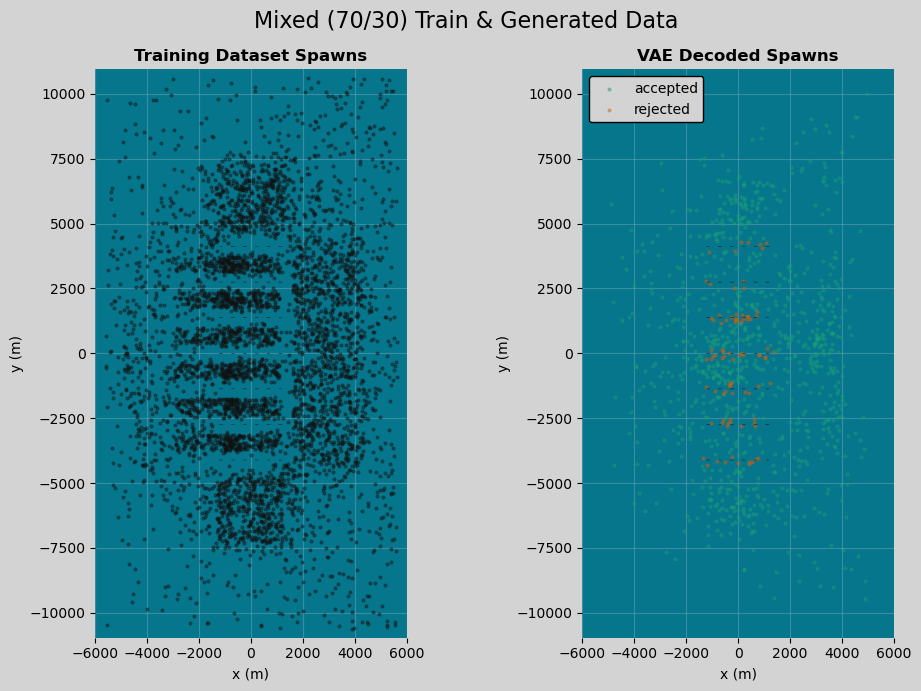

In [14]:
train_records = load_dataset_records(PROJECT_ROOT / TRAIN_PATH)
train_rows = flatten_dataset_records(train_records[: int(TRAIN_COMPARE_LIMIT)])
train_df = pd.DataFrame(train_rows)
train_df["u_pos"] = train_df[["u_pos_x", "u_pos_y"]].values.tolist()

train_points = np.vstack(train_df["u_pos"].to_list()) if len(train_df) else None
vae_points = np.vstack(audit_df["u_pos"].to_list()) if len(audit_df) else None
extra_sets = [p for p in [train_points, vae_points] if p is not None]
shared_limits = combined_limits(AUDIT_SHIPS, extra_points=np.vstack(extra_sets) if extra_sets else None, pad=350.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 7), facecolor="lightgrey")
style_ax(axes[0], "Training Dataset Spawns")
simple_ship_polygons(axes[0], AUDIT_SHIPS)
if len(train_df):
    train_xy = np.vstack(train_df["u_pos"].to_list())
    axes[0].scatter(train_xy[:, 0], train_xy[:, 1], c="#111111", s=4, alpha=0.4, zorder=2)
apply_limits(axes[0], shared_limits, fixed_x_limits=FIXED_X_LIMITS)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")

plot_spawn_comparison(
    axes[1],
    AUDIT_SHIPS,
    audit_df,
    title="VAE Decoded Spawns",
    accepted_only=False,
    limits=shared_limits,
)
axes[1].legend(loc="upper left", frameon=True, facecolor="lightgrey", edgecolor="black", framealpha=1.0,)
apply_limits(axes[1], shared_limits, fixed_x_limits=FIXED_X_LIMITS)
fig.suptitle("Mixed (70/30) Train & Generated Data", fontsize=16)
plt.savefig("VAE_Mixed.png")
plt.tight_layout()
plt.show()


In [15]:
feature_rows = []
for feature_name, mean, std in zip(
    AUDIT_PREPROCESSOR.feature_names,
    AUDIT_PREPROCESSOR.mean,
    AUDIT_PREPROCESSOR.std,
):
    feature_rows.append({"feature": feature_name, "mean": float(mean), "std": float(std)})
pd.DataFrame(feature_rows)


,feature,mean,std
0,u_pos_x,427.189026,2397.998535
1,u_pos_y,-45.286934,4313.841797
2,sin_base_bearing_rad,0.003446,0.783927
3,cos_base_bearing_rad,0.077631,0.615965
4,spread_rad,0.071421,0.024855
5,launch_delay_s,1.495936,0.602414
6,salvo_interval_s,2.249211,0.559573
7,u_boat_initial_speed_mps,1.495559,0.316379
